**1. Dataset**

We use California Housing:

8 numerical features (e.g., avg rooms, location)

Target: median house value


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

In [ ]:
data = fetch_california_housing()
X = data.data
y = data.target
feature_names = data.feature_names

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Why Scaling Is Required**

Regularization penalizes weights proportional to their magnitude.
If features are on different scales, penalties become meaningless.

In [ ]:
# Standardize features (important for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [ ]:
models = {
    "No Regularization": LinearRegression(),
    "L2 (Ridge)": Ridge(alpha=1.0),
    "L1 (Lasso)": Lasso(alpha=0.01),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5)
}



In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred  = model.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse  = mean_squared_error(y_test,  y_test_pred)

    results[name] = {
        "train_mse": train_mse,
        "test_mse": test_mse,
        "weights": model.coef_
    }

In [ ]:
df_results = pd.DataFrame(results).T
print(df_results[["train_mse", "test_mse"]])


                  train_mse  test_mse
No Regularization  0.517933  0.555892
L2 (Ridge)         0.517933  0.555855
L1 (Lasso)         0.523384  0.548255
Elastic Net        0.521155  0.549953


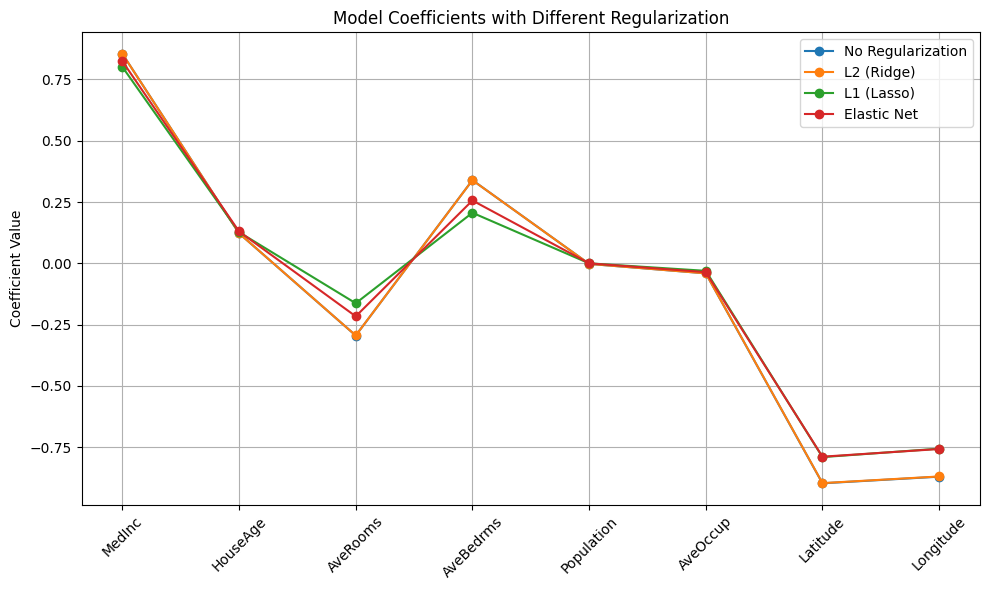

In [ ]:
plt.figure(figsize=(10,6))
for name in results:
    plt.plot(feature_names, results[name]["weights"], marker='o', label=name)

plt.xticks(rotation=45)
plt.ylabel("Coefficient Value")
plt.title("Model Coefficients with Different Regularization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

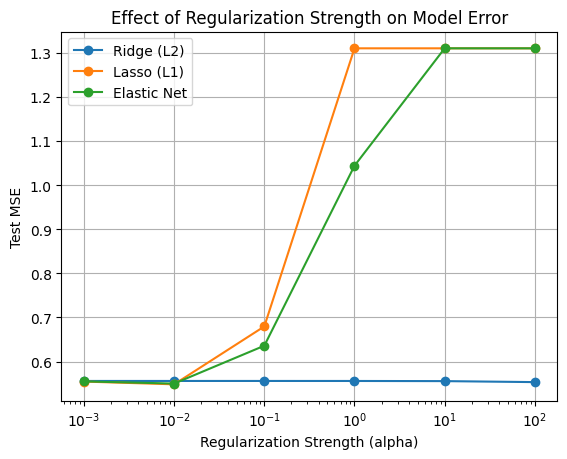

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_errors = []
lasso_errors = []
elastic_errors = []

for a in alphas:
    ridge = Ridge(alpha=a)
    lasso = Lasso(alpha=a)
    elastic = ElasticNet(alpha=a, l1_ratio=0.5)

    ridge.fit(X_train_scaled, y_train)
    lasso.fit(X_train_scaled, y_train)
    elastic.fit(X_train_scaled, y_train)

    ridge_errors.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    lasso_errors.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    elastic_errors.append(mean_squared_error(y_test, elastic.predict(X_test_scaled)))

plt.plot(alphas, ridge_errors, marker='o', label="Ridge (L2)")
plt.plot(alphas, lasso_errors, marker='o', label="Lasso (L1)")
plt.plot(alphas, elastic_errors, marker='o', label="Elastic Net")

plt.xscale("log")
plt.xlabel("Regularization Strength (alpha)")
plt.ylabel("Test MSE")
plt.title("Effect of Regularization Strength on Model Error")
plt.legend()
plt.grid(True)
plt.show()
